# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from matplotlib import pyplot as plt
from IPython.core.display_functions import clear_output

# Load data

In [3]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master='Updated Nuc ID (Sept 2)'
seg_col_master='Updated Seg ID (Sept 2)'

df_merged = data_loader.load_df_rois_morph(
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

# Plot data

In [5]:
import numpy as np
import seaborn as sns

In [6]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):

    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

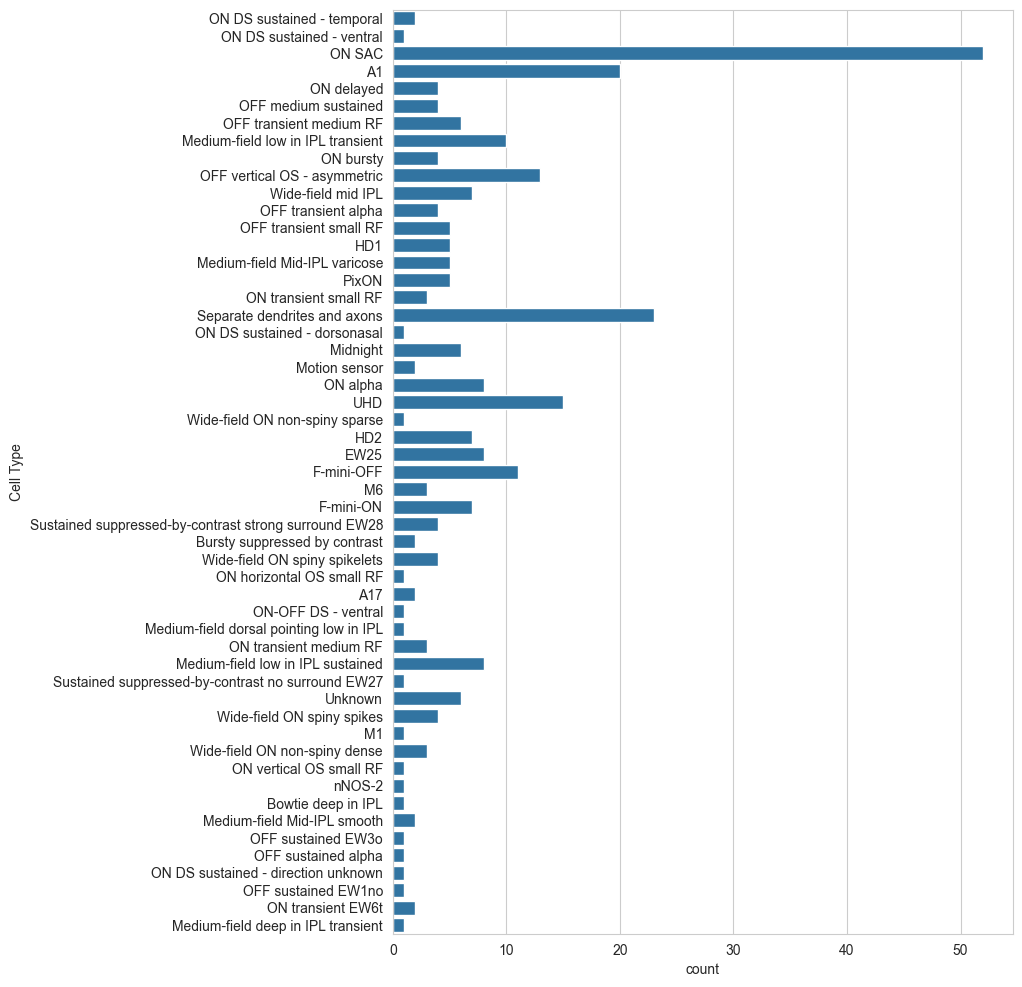

In [8]:
fig, ax = plt.subplots(1, 1 , figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [9]:
fig_dir = 'figures/adaptation_by_type'
os.makedirs(fig_dir, exist_ok=True)

for cell_type, df_group in df_merged.groupby('Cell Type'):
    clear_output()

    fig, axs = plt.subplots(1, 2, figsize=(7, 1 + 0.8 * len(df_group.groupby('field'))),
                            width_ratios=(4, 2), sharey=True)

    fig.suptitle(cell_type)

    sns.despine()

    offset = -2.0
    ax_chirp = axs[0]
    ax_bar = axs[1]

    yticks = []
    yticklabels = []

    for i, (field, df_plot) in enumerate(df_group.groupby('field')):
        t_chirp = np.arange(df_plot.chirp_average_norm.iloc[0].size) * df_plot.chirp_average_dt.iloc[0]
        t_bar = np.arange(df_plot.bar_time_component.iloc[0].size) * df_plot.bar_snippets_dt.iloc[0]

        chirps = np.vstack(df_plot.chirp_average_norm)
        bars = np.vstack(df_plot.bar_time_component)

        plot_mean_and_sd(ax=ax_chirp, traces=chirps, time=t_chirp, offset=i*offset, color='black', facealpha=0.2)
        plot_mean_and_sd(ax=ax_bar, traces=bars, time=t_bar, offset=i*offset, color='black', facealpha=0.2)

        yticks.append(i*offset)
        yticklabels.append(f"{field}\nn={df_plot.shape[0]}")

    axs[0].set_yticks(yticks)
    axs[0].set_yticklabels(yticklabels)
    for ax in axs:
        ax.set_xlabel('Time (s)')

    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f'response_adaptation_{cell_type}.pdf'))
    plt.close(fig)